In [1]:
import numpy as np
import xarray
import os
from matplotlib import pyplot as plt
import scipy.signal as scipy_signal
import scipy.stats as scipy_stats
from geopy import distance as geo_dist
import cmocean
import pandas
import proplot
import cartopy.feature as cfeature

/tube1/cha674/Anaconda_Install/miniconda/envs/py3/lib/python3.7/_collections_abc.py:841: MatplotlibDeprecationWarning: 
The examples.directory rcparam was deprecated in Matplotlib 3.0 and will be removed in 3.2. In the future, examples will be found relative to the 'datapath' directory.
  self[key] = other[key]


In [2]:
track_file_name = 'all_species_tracks.csv'

track_data_frame = pandas.read_csv(track_file_name)

In [3]:
track_data_frame.columns

Index(['id', 'date', 'lon', 'lat', 'species', 'age_group', 'breeding_stage',
       'trip_type'],
      dtype='object')

In [4]:
track_data_frame['species'].unique()

array(['AUSFS', 'LNFS', 'shy albatross', 'short-tailed shearwater'],
      dtype=object)

In [23]:
albatross = track_data_frame.loc[track_data_frame['species'] == 'AUSFS']


In [24]:
unique_ids = albatross['id'].unique()
print(len(unique_ids))

5


/tube1/cha674/Anaconda_Install/miniconda/envs/py3/lib/python3.7/site-packages/proplot/config.py:555: ProPlotWarning: rc setting 'share' was renamed to subplots.share in version 0.6.


<Figure size 2000x1000 with 0 Axes>

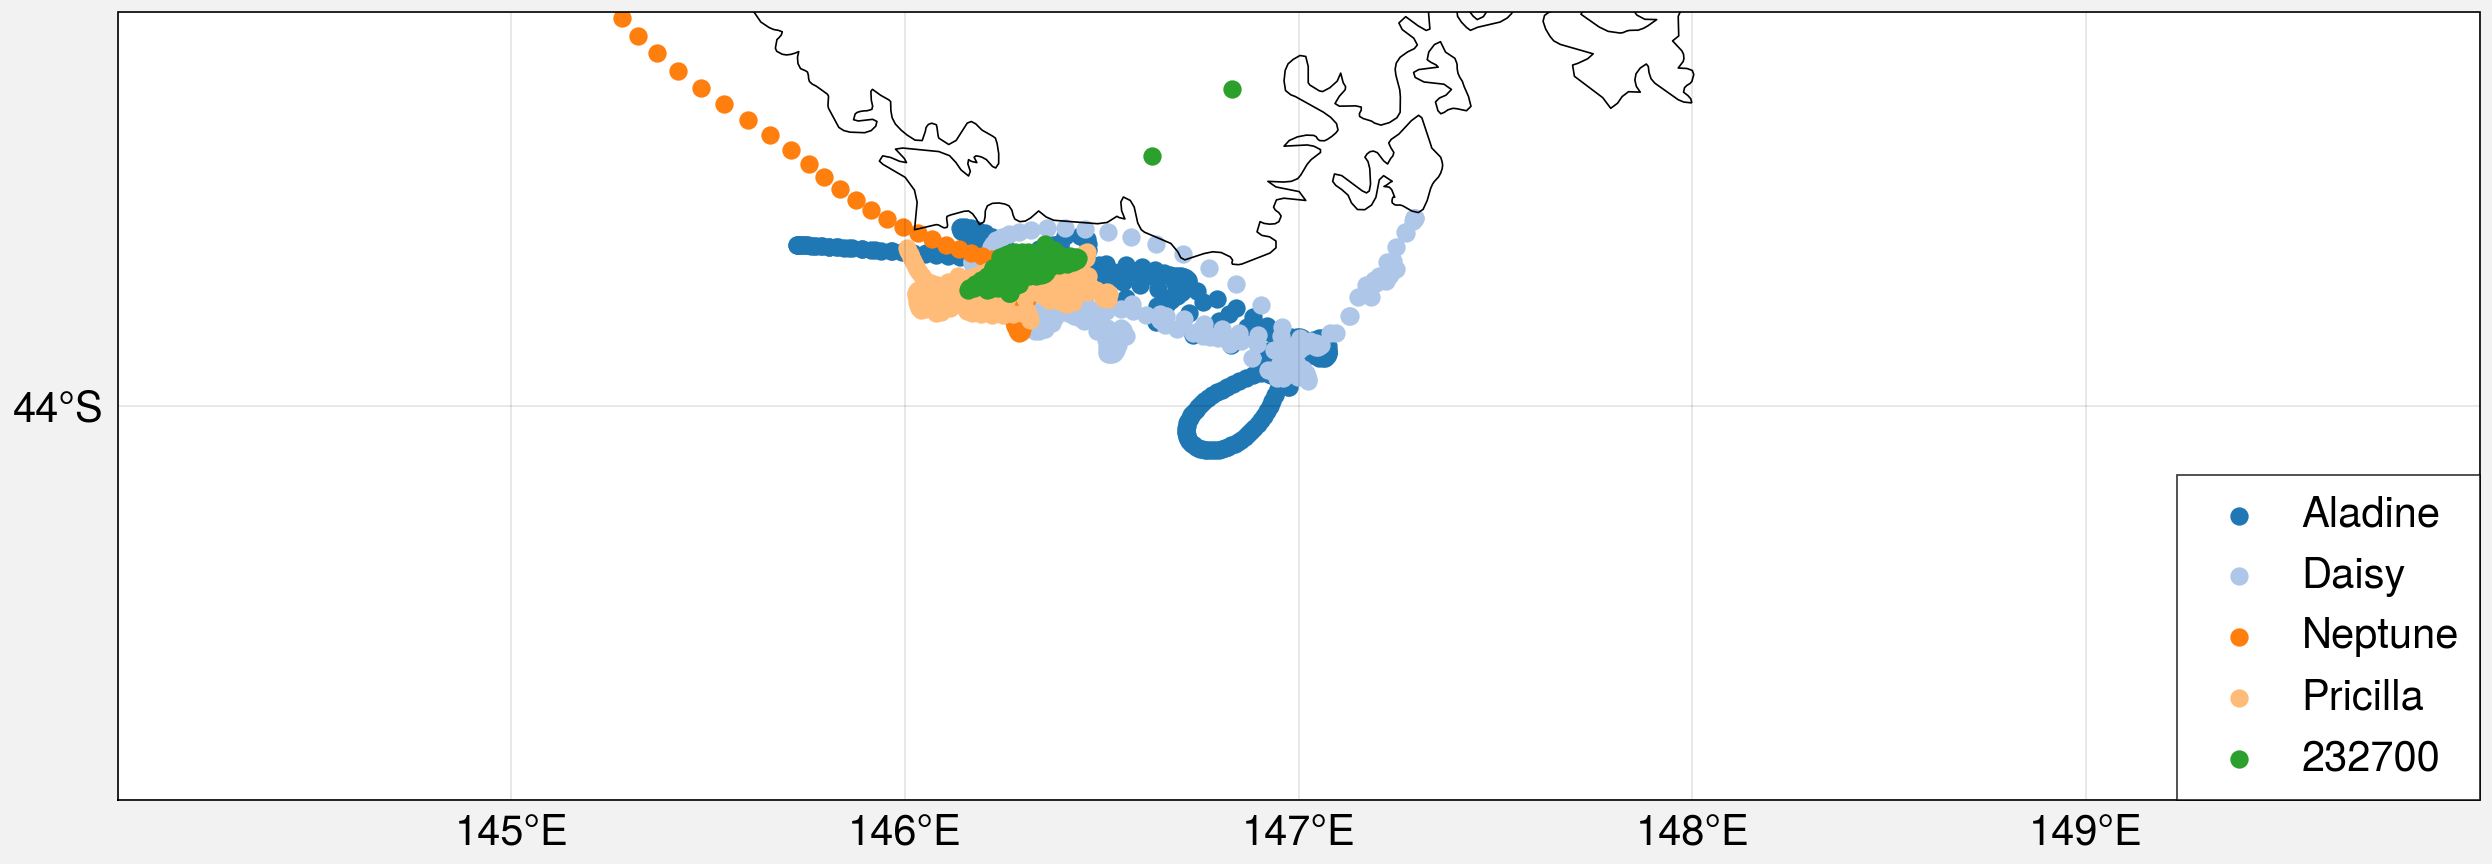

In [29]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes,mark_inset
import cartopy
import cartopy.crs as ccrs
from shapely.geometry.polygon import LinearRing


unique_ids = albatross['id'].unique()






proplot.rc['land.color'] = 'grey'
proplot.rc['text.labelsize'] = 15
proplot.rc['text.titlesize'] = 25
proplot.rc['abc.size'] = 15
proplot.rc['abc.style'] = 'a'
proplot.rc.reso = 'hi'

#SW Tas Domain
lon_min = 144
lon_max = 150
lat_min = -45
lat_max = -43


proj = proplot.Proj('cyl', basemap=False)


plt.figure(1,figsize=(20,10))
fig, axs = proplot.subplots(nrows=1, ncols=1,axwidth='30cm',aspect=2.5,proj=proj)
axs.format(abc=False,share=0) #, color='grey')


for i_animal in unique_ids:
    animal_to_follow = albatross.loc[albatross['id'] == i_animal]
    
    lat_animal = animal_to_follow['lat']
    lon_animal = animal_to_follow['lon']
    time_animal = pandas.to_datetime(animal_to_follow['date'].values)
    
    
    axs[0].scatter(lon_animal,lat_animal,label=str(i_animal),cycle='tab20')

axs[0].format(land=False,coast=True,facecolor='white',
                            lonlim=(lon_min, lon_max), latlim=(lat_min, lat_max), 
                            labels=True,lonlines=np.arange(0,360,1),latlines=np.arange(-80,50,1))
axs[0].legend(loc='lr',ncol=1)


/tube1/cha674/Anaconda_Install/miniconda/envs/py3/lib/python3.7/site-packages/proplot/config.py:555: ProPlotWarning: rc setting 'share' was renamed to subplots.share in version 0.6.


<Figure size 2000x1000 with 0 Axes>

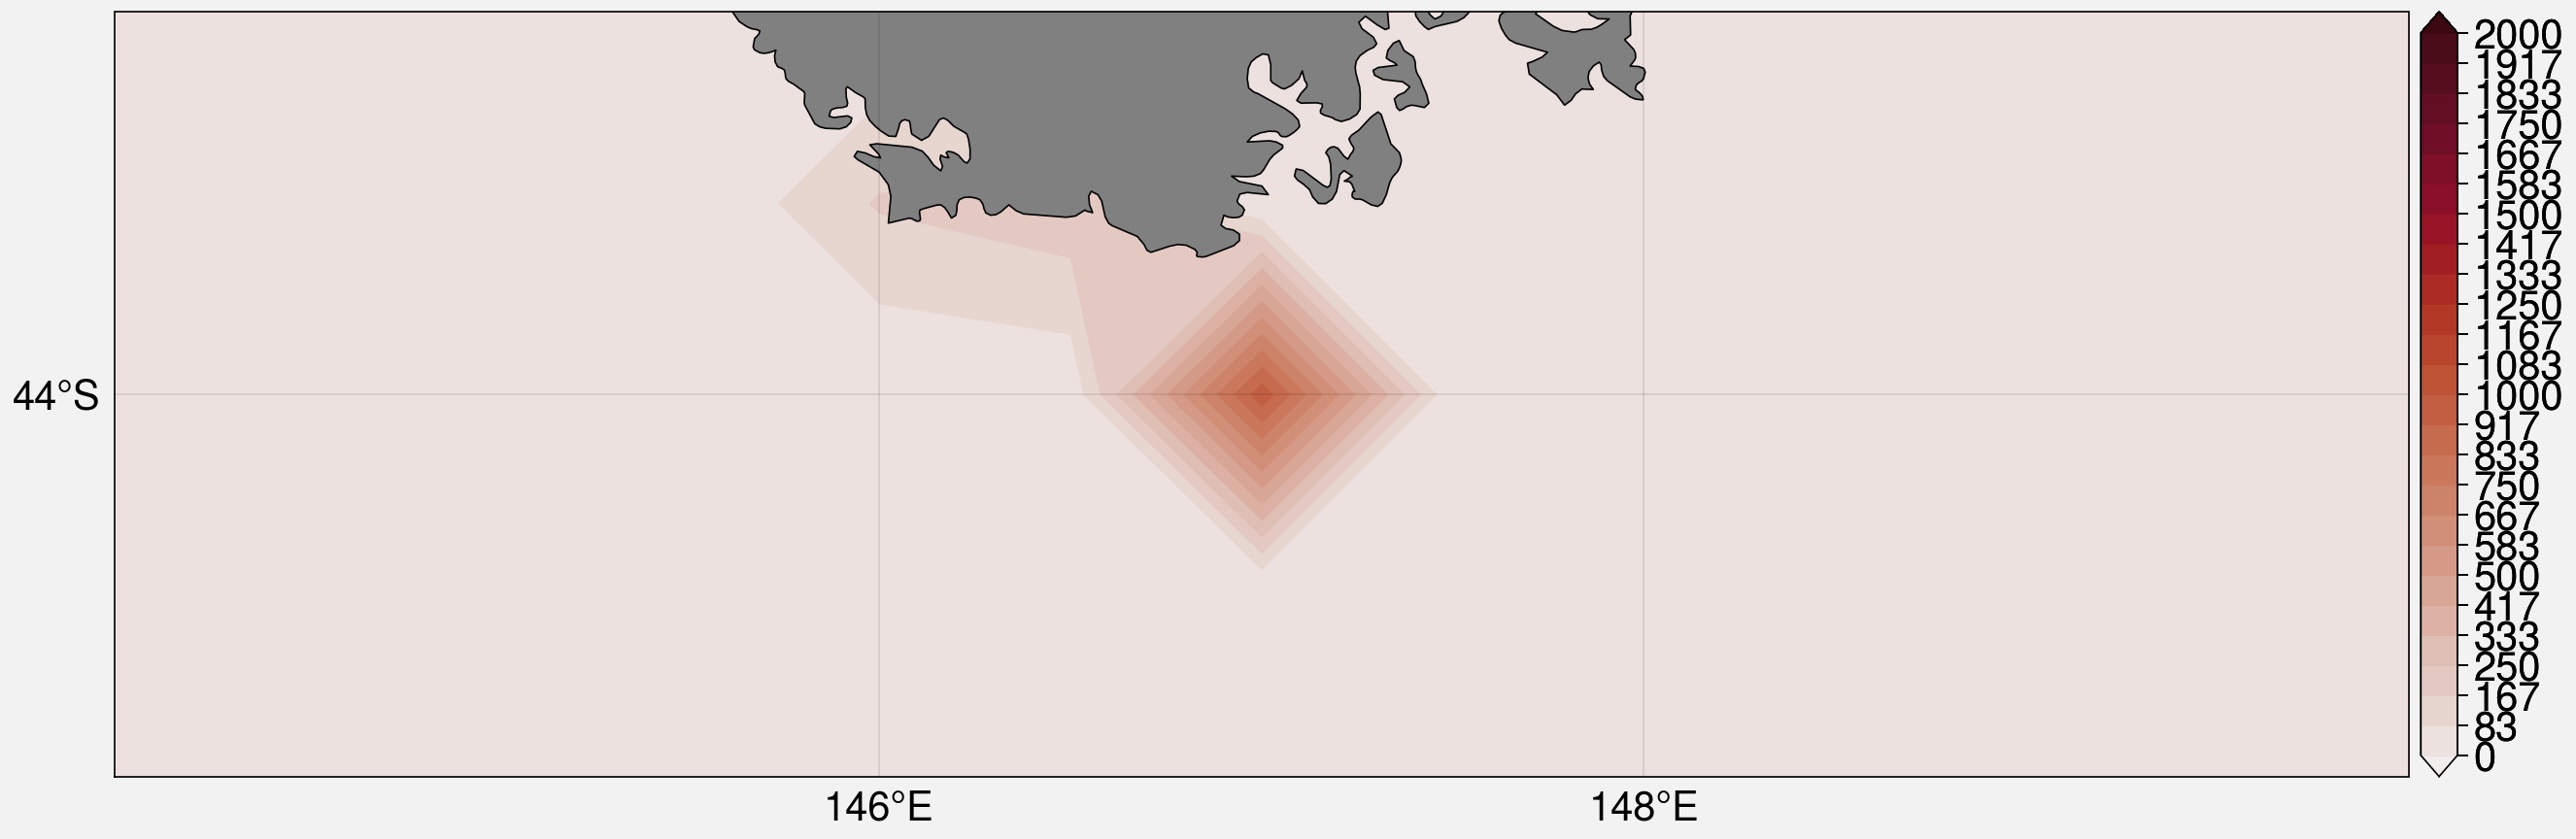

In [30]:
from sklearn.neighbors import KernelDensity



#SW Tas Domain
#SW Tas Domain
lon_min = 144
lon_max = 150
lat_min = -45
lat_max = -43

delta_lon = 0.5
delta_lat = 0.5

xgrid = np.arange(lon_min,lon_max+delta_lon,delta_lon)
ygrid = np.arange(lat_min,lat_max+delta_lat,delta_lat)

X, Y = np.meshgrid(xgrid, ygrid[::-1])
xy = np.vstack([Y.ravel(), X.ravel()]).T
xy *= np.pi / 180.0



Xtrain = np.vstack([albatross["lat"],albatross["lon"]]).T
Xtrain = (np.pi/180.0)*Xtrain  # Convert lat/long to radians

kde = KernelDensity(bandwidth=0.001, metric="haversine", kernel="gaussian", algorithm="ball_tree")
KDE_fit = kde.fit(Xtrain).score_samples(xy)
KDE_fit = np.exp(KDE_fit.reshape(X.shape))





proplot.rc['land.color'] = 'grey'
proplot.rc['text.labelsize'] = 15
proplot.rc['text.titlesize'] = 25
proplot.rc['abc.size'] = 15
proplot.rc['abc.style'] = 'a'
proplot.rc.reso = 'hi'

proj = proplot.Proj('cyl', basemap=False)


plt.figure(1,figsize=(20,10))
fig, axs = proplot.subplots(nrows=1, ncols=1,axwidth='30cm',aspect=2.5,proj=proj)
axs.format(abc=False,share=0) #, color='grey')
cs_kde = axs[0].contourf(X,Y,KDE_fit,levels=np.linspace(0,2000,25),cmap='amp',extend='both')
#axs[0].scatter(albatross["lon"],albatross["lat"],c='k',alpha=0.05)
axs[0].format(land=True,coast=True,facecolor='white',
                            lonlim=(lon_min, lon_max), latlim=(lat_min, lat_max), 
                            labels=True,lonlines=np.arange(0,360,2),latlines=np.arange(-50,50,1))
axs[0].colorbar(cs_kde)

In [31]:
albatros_date = pandas.to_datetime(albatross['date'].values)

start_date = albatros_date.min()
end_date  = albatros_date.max()

In [13]:
start_date

Timestamp('2022-11-05 23:59:00+0000', tz='UTC')

In [24]:
#sst_dataset_2022 = xarray.open_dataset('TAS_GHRSST_foundation_SST.1992.2022.nc').sel(time=slice('2022-01-01','2023-01-01'))
#sst_dataset_2023 = xarray.open_dataset('TAS_GHRSST_foundation_SST.2023.nc').drop_vars('quality_level')

#sst_dataset = xarray.concat([sst_dataset_2022['sst'].to_dataset(),sst_dataset_2023],dim='time')
sst_dataset = xarray.open_dataset('GHRSST_foundation_Bight_and_Tas.2022_2023.nc')


In [91]:
date_range

DatetimeIndex(['2022-09-28 23:40:00', '2022-09-29 00:40:00',
               '2022-09-29 01:40:00', '2022-09-29 02:40:00',
               '2022-09-29 03:40:00', '2022-09-29 04:40:00',
               '2022-09-29 05:40:00', '2022-09-29 06:40:00',
               '2022-09-29 07:40:00', '2022-09-29 08:40:00',
               ...
               '2023-04-27 03:40:00', '2023-04-27 04:40:00',
               '2023-04-27 05:40:00', '2023-04-27 06:40:00',
               '2023-04-27 07:40:00', '2023-04-27 08:40:00',
               '2023-04-27 09:40:00', '2023-04-27 10:40:00',
               '2023-04-27 11:40:00', '2023-04-27 12:40:00'],
              dtype='datetime64[ns]', length=5054, freq='H')

In [34]:
albatros_date = pandas.to_datetime(albatross['date'].values)
albatros_date = albatros_date.tz_localize(None)

animal_colors = proplot.Colors('tab20')

start_date = albatros_date.min()
end_date  = albatros_date.max()



start_date = '2023-01-10'

date_range = pandas.date_range(start_date,end_date,freq='1H')

#SW Tas Domain
lon_min = 144
lon_max = 150
lat_min = -45
lat_max = -43





#sst_for_albatros = sst_dataset.sel(time=slice(start_date,end_date))
#sst_time_albatros = pandas.to_datetime(sst_for_albatros['time'].dt.round('D'))
#sst_time.tz_localize(None)


image_counter = 0
for i_time in range(0,date_range.size-1):
    #(df['column_name'] >= A) & (df['column_name'] <= B)
    #print(sst_time_albatros[i_time])
    #dsa
    albatros_tracks_for_date = albatross.loc[(albatros_date>date_range[i_time]-np.timedelta64(1,'D')) & (albatros_date<date_range[i_time+1]) ]
    
    
    
    plt.figure(1,figsize=(20,10))
    fig, axs = proplot.subplots(nrows=1, ncols=1,axwidth='30cm',aspect=2.5,proj=proj)
    axs.format(abc=False,share=0) #, color='grey')
    #cs_sst = axs.contourf(sst_dataset['lon'],sst_dataset['lat'],sst_for_albatros['sst'][i_time,:,:],levels=np.linspace(10,22,25),cmap='thermal')
    
    for i_animal in range(0,len(unique_ids)):
        
        animal_to_follow = albatros_tracks_for_date.loc[albatross['id'] == unique_ids[i_animal]]
        lat_animal  = animal_to_follow['lat'].values
        lon_animal  = animal_to_follow['lon'].values
        time_animal = pandas.to_datetime(animal_to_follow['date'].values)
    
        if len(lat_animal) != 0:
            axs[0].plot(lon_animal,lat_animal,color=animal_colors[i_animal],linestyle='--' )
            axs[0].scatter(lon_animal[-1],lat_animal[-1],c=np.asarray([animal_colors[i_animal]]),markersize=70 )

    
    #END for i_animal
    axs[0].format(land=True,coast=True,facecolor='white',
                            lonlim=(lon_min, lon_max), latlim=(lat_min, lat_max), 
                            labels=True,lonlines=np.arange(0,360,10),latlines=np.arange(-80,50,5))

    
    date_plot_string = date_range[i_time].strftime("%d %B %Y:%H")
    print(date_plot_string)
    #axs[0].colorbar(cs_sst,loc='r',ticks=np.arange(10,22.1,5))
    axs[0].annotate(date_plot_string, xy=(0.05, 1.01), xycoords="axes fraction",fontsize=20)
    
    
    output_path = './AFS_animation'
    figure_file_name = 'AFS_frame_' +  str(image_counter).zfill(5)
    
    
    
    plt.savefig(os.path.join(output_path,figure_file_name + '.png'),dpi=100)
    image_counter = image_counter+1
    
    plt.clf()
    
    

/tube1/cha674/Anaconda_Install/miniconda/envs/py3/lib/python3.7/site-packages/proplot/config.py:555: ProPlotWarning: rc setting 'share' was renamed to subplots.share in version 0.6.


10 January 2023:00


/tube1/cha674/Anaconda_Install/miniconda/envs/py3/lib/python3.7/site-packages/proplot/config.py:555: ProPlotWarning: rc setting 'share' was renamed to subplots.share in version 0.6.


10 January 2023:01


/tube1/cha674/Anaconda_Install/miniconda/envs/py3/lib/python3.7/site-packages/proplot/config.py:555: ProPlotWarning: rc setting 'share' was renamed to subplots.share in version 0.6.


...

<Figure size 1193.6x430.278 with 0 Axes>

<Figure size 1193.6x430.278 with 0 Axes>

<Figure size 1193.6x430.278 with 0 Axes>

<Figure size 1193.6x430.278 with 0 Axes>

<Figure size 1193.6x430.278 with 0 Axes>

In [93]:
albatros_tracks_for_date

,id,date,lon,lat,species,age_group,breeding_stage,trip_type
14795,76,2022-09-29T00:09:00Z,146.371270,-43.737222,shy albatross,adult,incubation,NaN
15304,80,2022-09-28T23:40:00Z,146.371673,-43.736597,shy albatross,adult,incubation,NaN
17167,82,2022-09-29T00:30:00Z,146.371215,-43.737285,shy albatross,adult,incubation,NaN


2022-09-30 00:00:00


/tube1/cha674/Anaconda_Install/miniconda/envs/py3/lib/python3.7/site-packages/proplot/config.py:555: ProPlotWarning: rc setting 'share' was renamed to subplots.share in version 0.6.


NameError: name 'das' is not defined

<Figure size 2000x1000 with 0 Axes>

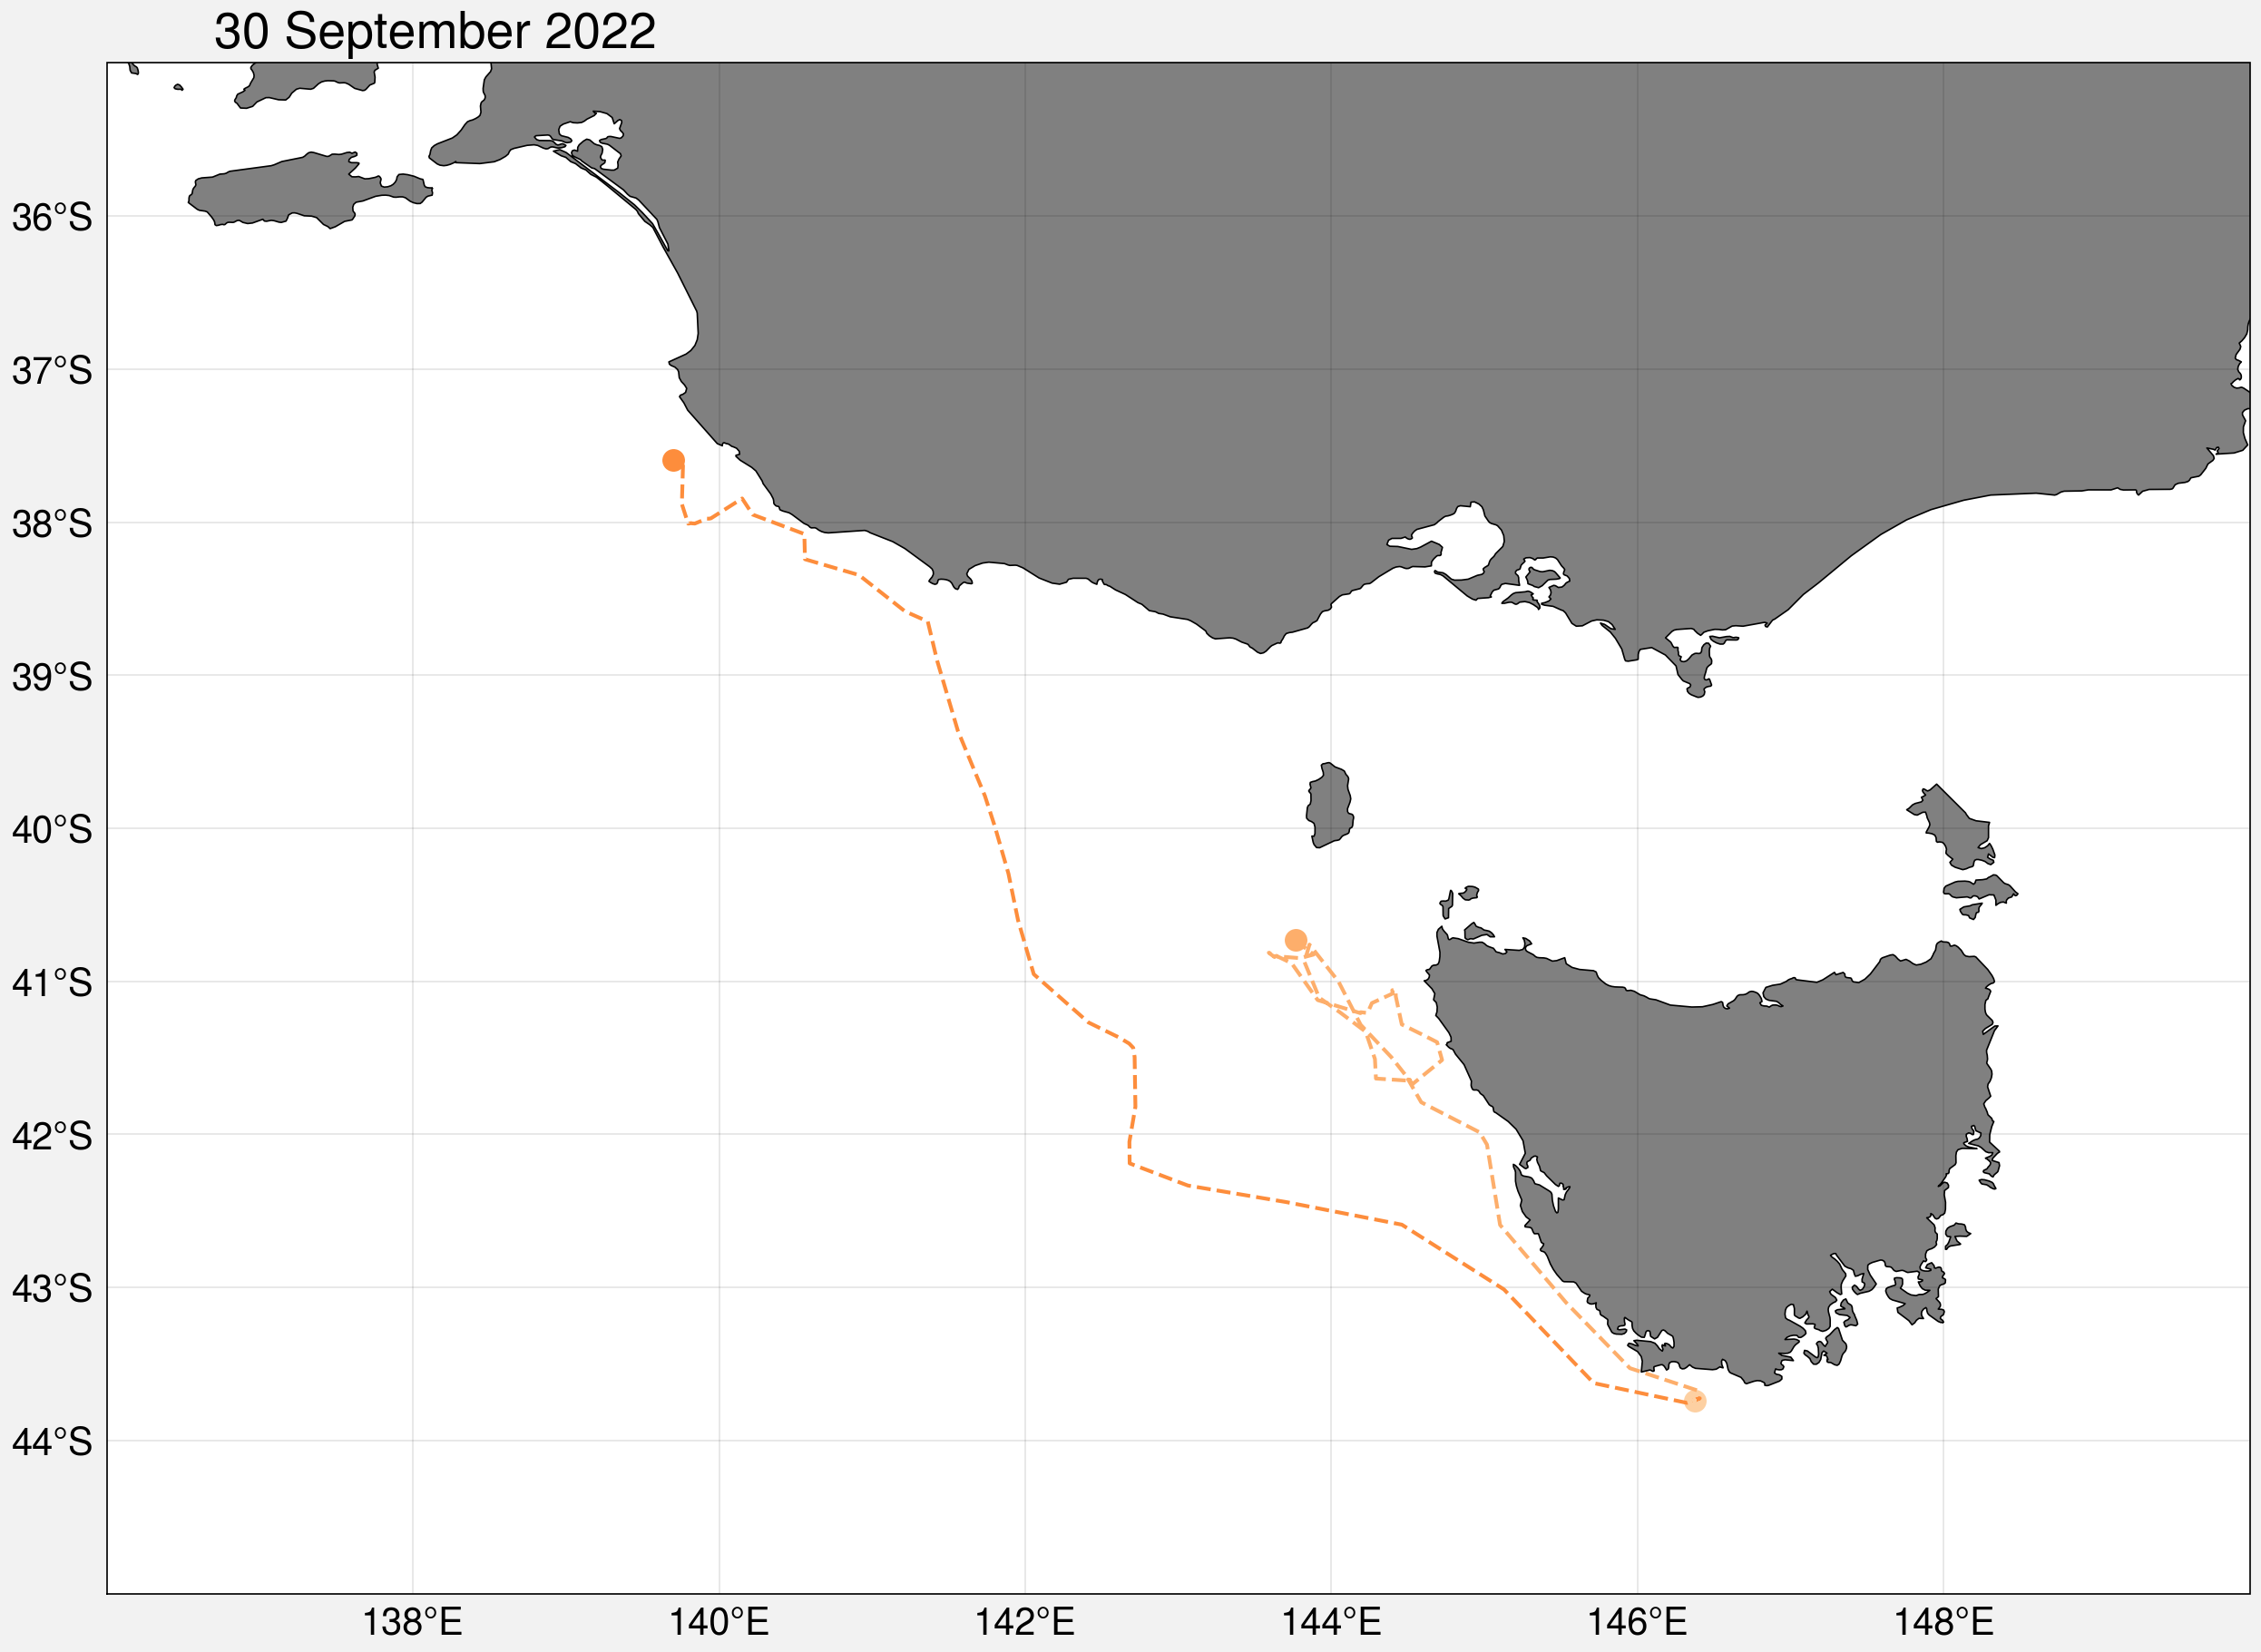

In [89]:
albatros_date = pandas.to_datetime(albatross['date'].values)
albatros_date = albatros_date.tz_localize(None)

animal_colors = proplot.Colors('tab20c')

start_date = albatros_date.min()
end_date  = albatros_date.max()

sst_for_albatros = sst_dataset.sel(time=slice(start_date,end_date))
sst_time_albatros = pandas.to_datetime(sst_for_albatros['time'].dt.round('D'))
#sst_time.tz_localize(None)


image_counter = 0
for i_time in range(0,sst_time_albatros.size-1):
    #(df['column_name'] >= A) & (df['column_name'] <= B)
    print(sst_time_albatros[i_time])
    #dsa
    albatros_tracks_for_date = albatross.loc[(albatros_date>sst_time_albatros[i_time]-np.timedelta64(1,'D')) & (albatros_date<sst_time_albatros[i_time+1]) ]
    
    
    
    plt.figure(1,figsize=(20,10))
    fig, axs = proplot.subplots(nrows=1, ncols=1,axwidth='30cm',aspect=2.5,proj=proj)
    axs.format(abc=False,share=0) #, color='grey')
    #cs_sst = axs.contourf(sst_dataset['lon'],sst_dataset['lat'],sst_for_albatros['sst'][i_time,:,:],levels=np.linspace(10,22,25),cmap='thermal')
    
    for i_animal in range(0,len(unique_ids)):
        
        animal_to_follow = albatros_tracks_for_date.loc[albatross['id'] == unique_ids[i_animal]]
        lat_animal  = animal_to_follow['lat'].values
        lon_animal  = animal_to_follow['lon'].values
        time_animal = pandas.to_datetime(animal_to_follow['date'].values)
    
        if len(lat_animal) != 0:
            axs[0].plot(lon_animal,lat_animal,color=animal_colors[i_animal],linestyle='--' )
            axs[0].scatter(lon_animal[-1],lat_animal[-1],c=np.asarray([animal_colors[i_animal]]),markersize=70 )

    
    #END for i_animal
    axs[0].format(land=True,coast=True,facecolor='white',
                            lonlim=(lon_min, lon_max), latlim=(lat_min, lat_max), 
                            labels=True,lonlines=np.arange(0,360,2),latlines=np.arange(-50,50,1))

    
    date_plot_string = sst_time_albatros[i_time].strftime("%d %B %Y")
    #axs[0].colorbar(cs_sst,loc='r',ticks=np.arange(10,22.1,5))
    axs[0].annotate(date_plot_string, xy=(0.05, 1.01), xycoords="axes fraction",fontsize=20)
    output_path = './albatross_animation'
    figure_file_name = 'albatros_frame_' +  str(image_counter).zfill(4) 
    plt.savefig(os.path.join(output_path,figure_file_name + '.png'),dpi=200)
    image_counter = image_counter+1
    #das
    
    
    
    





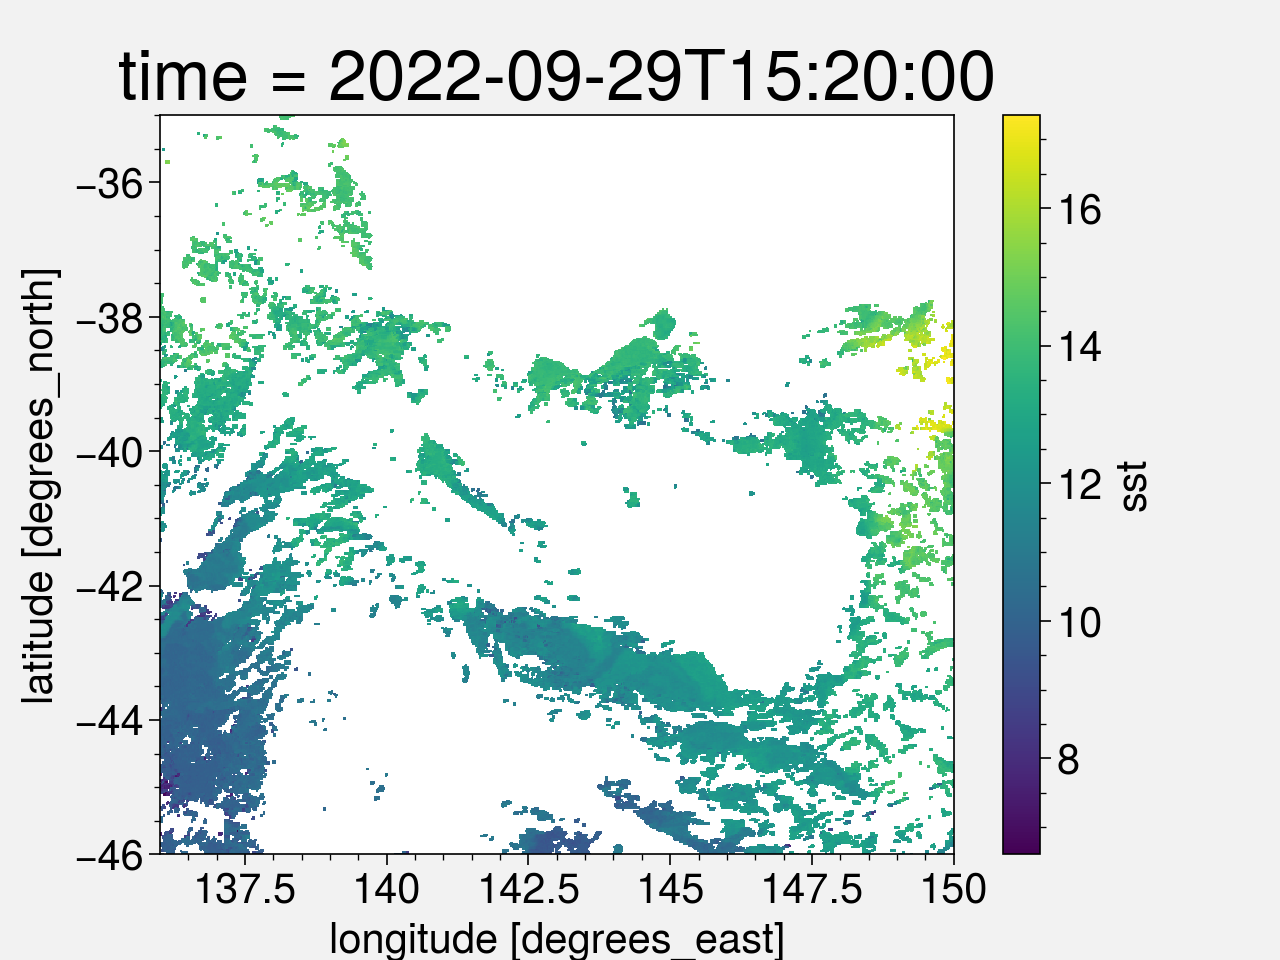

In [87]:
sst_for_albatros['sst'][i_time,:,:].plot()

In [70]:
sst_for_albatros

DatetimeIndex(['2022-09-30', '2022-10-01', '2022-10-02', '2022-10-03',
               '2022-10-04', '2022-10-05', '2022-10-06', '2022-10-07',
               '2022-10-08', '2022-10-09',
               ...
               '2023-04-18', '2023-04-19', '2023-04-20', '2023-04-21',
               '2023-04-22', '2023-04-23', '2023-04-24', '2023-04-25',
               '2023-04-26', '2023-04-27'],
              dtype='datetime64[ns]', length=210, freq=None)

In [54]:
len(lon_animal)

0

In [115]:
albatros_tracks_for_date

,id,date,lon,lat,species,age_group,breeding_stage,trip_type
14819,76,2022-09-30T00:09:00Z,141.736411,-39.788770,shy albatross,adult,incubation,NaN
14820,76,2022-09-30T01:09:00Z,141.559206,-39.361536,shy albatross,adult,incubation,NaN
14821,76,2022-09-30T02:09:00Z,141.424030,-38.903860,shy albatross,adult,incubation,NaN
14822,76,2022-09-30T03:09:00Z,141.363252,-38.649238,shy albatross,adult,incubation,NaN
14823,76,2022-09-30T04:09:00Z,141.214354,-38.583003,shy albatross,adult,incubation,NaN
...,...,...,...,...,...,...,...,...
17210,82,2022-09-30T19:30:00Z,146.371685,-43.737178,shy albatross,adult,incubation,NaN
17211,82,2022-09-30T20:30:00Z,146.370557,-43.737162,shy albatross,adult,incubation,NaN
17212,82,2022-09-30T21:30:00Z,146.370780,-43.737097,shy albatross,adult,incubation,NaN
17213,82,2022-09-30T22:30:00Z,146.370808,-43.736985,shy albatross,adult,incubation,NaN


In [111]:
albatros_date[0]

Timestamp('2022-10-01 03:09:00+0000', tz='UTC')